# Five numbers, and the point that sits alone

A box plot compresses a sample to a median, two quartiles, two whiskers, and any points beyond the whiskers. Matplotlib's quartiles use this index on the sorted sample. For a fraction $p$,

$$
\text{index} = (n-1)\,p
$$

If the index is a whole number, read that position, counting from zero. If the index is $k + f$ with a fraction $f$, take $(1-f)$ of the value at $k$ plus $f$ of the value at $k+1$.

Nine reaction times, already sorted:

$$
3, 5, 6, 7, 8, 9, 12, 14, 22
$$

Here $n-1 = 8$.

$$
\begin{aligned}
25\% &\colon \text{index } 2 &&\rightarrow 6 \\
50\% &\colon \text{index } 4 &&\rightarrow 8 \\
75\% &\colon \text{index } 6 &&\rightarrow 12
\end{aligned}
$$

The interquartile range is $12-6 = 6$. The whiskers stop at the last points inside $1.5$ times that range of the quartiles:

$$
6 - 1.5\cdot 6 = -3, \qquad 12 + 1.5\cdot 6 = 21
$$

Every point from $3$ through $14$ is inside $[-3, 21]$. The value $22$ is not. The lower whisker ends at $3$, the upper whisker ends at $14$, and $22$ is drawn as its own point.


flier [np.int64(22)]


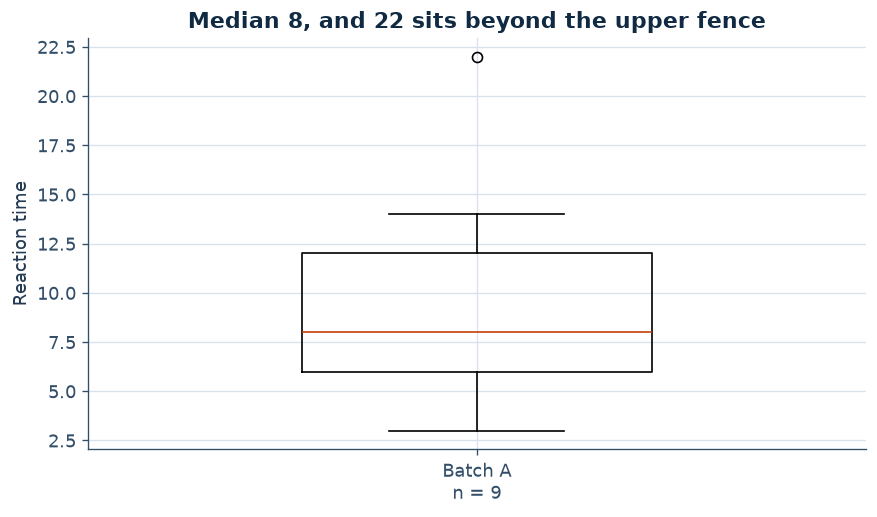

In [1]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# The box, the whiskers, and the lone point at 22, read back from the artists.
times = [3, 5, 6, 7, 8, 9, 12, 14, 22]
fig, ax = plt.subplots(constrained_layout=True)
drawn = ax.boxplot(times, whis=1.5, widths=0.45)
ax.set_ylabel("Reaction time")
ax.set_xticks([1], ["Batch A\nn = 9"])
ax.set_title("Median 8, and 22 sits beyond the upper fence")
assert drawn["medians"][0].get_ydata()[0] == 8
assert list(drawn["whiskers"][0].get_ydata()) == [6, 3]
assert list(drawn["whiskers"][1].get_ydata()) == [12, 14]
assert list(drawn["fliers"][0].get_ydata()) == [22]
print("flier", list(drawn["fliers"][0].get_ydata()))


## Same median, different width

Batch B, also nine values:

$$
6, 7, 7, 8, 8, 8, 9, 10, 11
$$

The same index rule gives quartiles $7$, $8$, and $9$. The range of the middle half is $2$. The fences are

$$
7 - 3 = 4, \qquad 9 + 3 = 12
$$

All nine points lie inside, so there is no lone point. The whiskers end at $6$ and $11$.

Both medians are $8$. Batch A is the wide one, and it is the one with a point at $22$. A chart of only the two medians would have called the batches equal.


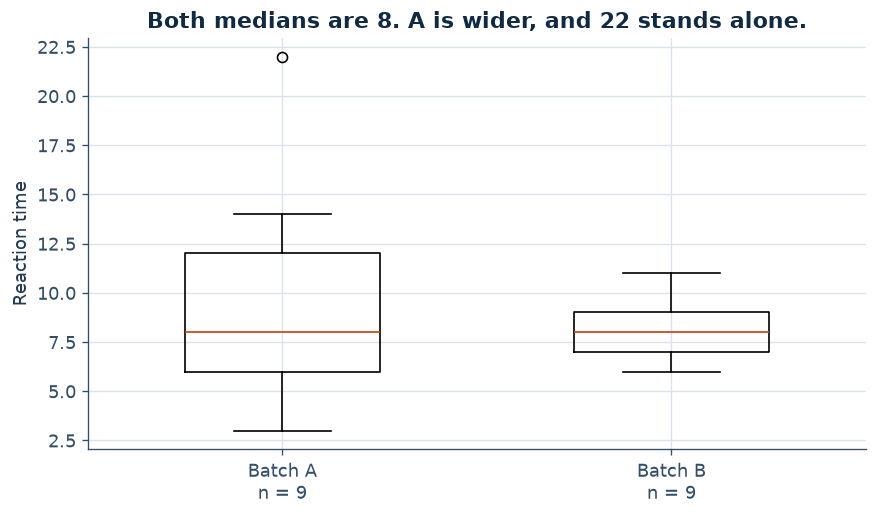

In [2]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# Two boxes. Equal medians do not mean equal spreads.
batch_a = [3, 5, 6, 7, 8, 9, 12, 14, 22]
batch_b = [6, 7, 7, 8, 8, 8, 9, 10, 11]
fig, ax = plt.subplots(constrained_layout=True)
drawn = ax.boxplot([batch_a, batch_b], whis=1.5, widths=0.5)
ax.set_ylabel("Reaction time")
ax.set_xticks([1, 2], ["Batch A\nn = 9", "Batch B\nn = 9"])
ax.set_title("Both medians are 8. A is wider, and 22 stands alone.")
assert drawn["medians"][0].get_ydata()[0] == 8
assert drawn["medians"][1].get_ydata()[0] == 8
assert list(drawn["fliers"][0].get_ydata()) == [22]
assert len(drawn["fliers"][1].get_ydata()) == 0
assert list(drawn["whiskers"][2].get_ydata()) == [7, 6]
assert list(drawn["whiskers"][3].get_ydata()) == [9, 11]


## A pitfall

The box does not show how many points built it. A box from $9$ runs can look identical to a box from $900$ runs. Put $n$ in the tick label. Also, $22$ is outside the fence rule above. It is not automatically a broken sensor. It is a point to look at, with its raw value still visible.

## What to carry forward

Sort, then read index $(n-1)p$. For batch A the quartiles are $6$, $8$, and $12$, the whiskers end at $3$ and $14$, and $22$ is drawn alone. Batch B has the same median and no lone point.
